In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyneb as pn
import yt
from matplotlib.colors import LogNorm
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.axes_grid1 import AxesGrid

### Computing the Continuous Spectrum with PyNeb

In [2]:
# function to compute the continuous spectrum (already implemented in PyNeb; no need to redefine it here)
class Continuum(object):
    def get_continuum(self, tem, den, He1_H=0., He2_H=0., wl=np.array([3500, 3600, 3700, 3800, 3900]), 
                      cont_HI=True, cont_HeI=True, cont_HeII=True, 
                      cont_2p=True, cont_ff=True, HI_label='11_2'):
        """
        
        Type of continuum to take into acount defined a boolean, defaults are True
        
        Parameters:
            tem: temperature [K]. May be a float or an iterable.
            den: density [cm-3]. May be a float or an iterable. If iterable, must have same size than tem.
            He1_H (float):  He+/H+ abundance. Default = 0.0
            He2_H (float): He++/H+ abundances.  Default = 0.0
            wl (np.array): Wavelengths Default = np.array([3500, 3600, 3700, 3800, 3900])
            cont_HI (bool): using B. Ercolano 2006 data. Default: True
            cont_HeI (bool): using B. Ercolano 2006 data. Default: True
            cont_HeII (bool): using B. Ercolano 2006 data. Default: True
            cont_2p (bool): 2 photons, using D. Pequignot fit to Osterbrock. Default: True
            cont_ff (bool): from Storey & Hummer 1991. Default: True
            
            HI_label (str): HI label to normalize the continuum. If None, no normalization is done. Default: '11_2'
            
        Returns:
            The resulting continuum. Unit [A-1] if normalized, [erg/s.cm3/A] otherwise
        
        Exemple of use:
            C = pn.Continuum()
            wl = np.arange(3500, 4000, 1)
            cont = C.get_continuum(tem=1e4, den=1e2, He1_H=0.08, He2_H=0.02, wl=wl)
            plt.plot(wl, cont)
        """
        try:
            _ = (e for e in tem)
            T_iterable = True
            try:
                _ = (e for e in den)
            except:
                den = np.ones_like(tem) * den
            try:
                _ = (e for e in He1_H)
            except:
                He1_H = np.ones_like(tem) * He1_H
            try:
                _ = (e for e in He2_H)
            except:
                He2_H = np.ones_like(tem) * He2_H
            
        except TypeError:
            T_iterable = False
        if HI_label is None:
            norm = 1.0
        else:
            if self.HI is None:
                self.HI = pn.RecAtom('H',1)
            norm = self.HI.getEmissivity(tem, den, label = HI_label, product=False)
            
        if T_iterable:
            cont = np.array(list(map(lambda t, d, He1_H_1,He2_H_1 : self._get_continuum1(t, d, 
                                                                                  He1_H=He1_H_1, 
                                                                                  He2_H=He2_H_1, 
                                                                                  wl=wl, 
                                                                                  cont_HI=cont_HI, 
                                                                                  cont_HeI=cont_HeI, 
                                                                                  cont_HeII=cont_HeII, 
                                                                                  cont_2p=cont_2p, 
                                                                                  cont_ff=cont_ff), 
                                     tem, den, He1_H, He2_H))).T
            return cont.squeeze()/norm
        else:
            cont = self._get_continuum1(tem, den, He1_H=He1_H, He2_H=He2_H, wl=wl, 
                                        cont_HI=cont_HI, cont_HeI=cont_HeI, cont_HeII=cont_HeII, 
                                        cont_2p=cont_2p, cont_ff=cont_ff)
            return cont/norm

/opt/anaconda3/lib/python3.12/site-packages/pyneb/core/continuum.py:135: RuntimeWarning: invalid value encountered in power
  A = 202.0 * (y * (1. - y) * (1. -(4. * y * (1 - y))**0.8) + 0.88 * ( y * (1 - y))**1.53 * (4. * y * (1 - y))**0.8)


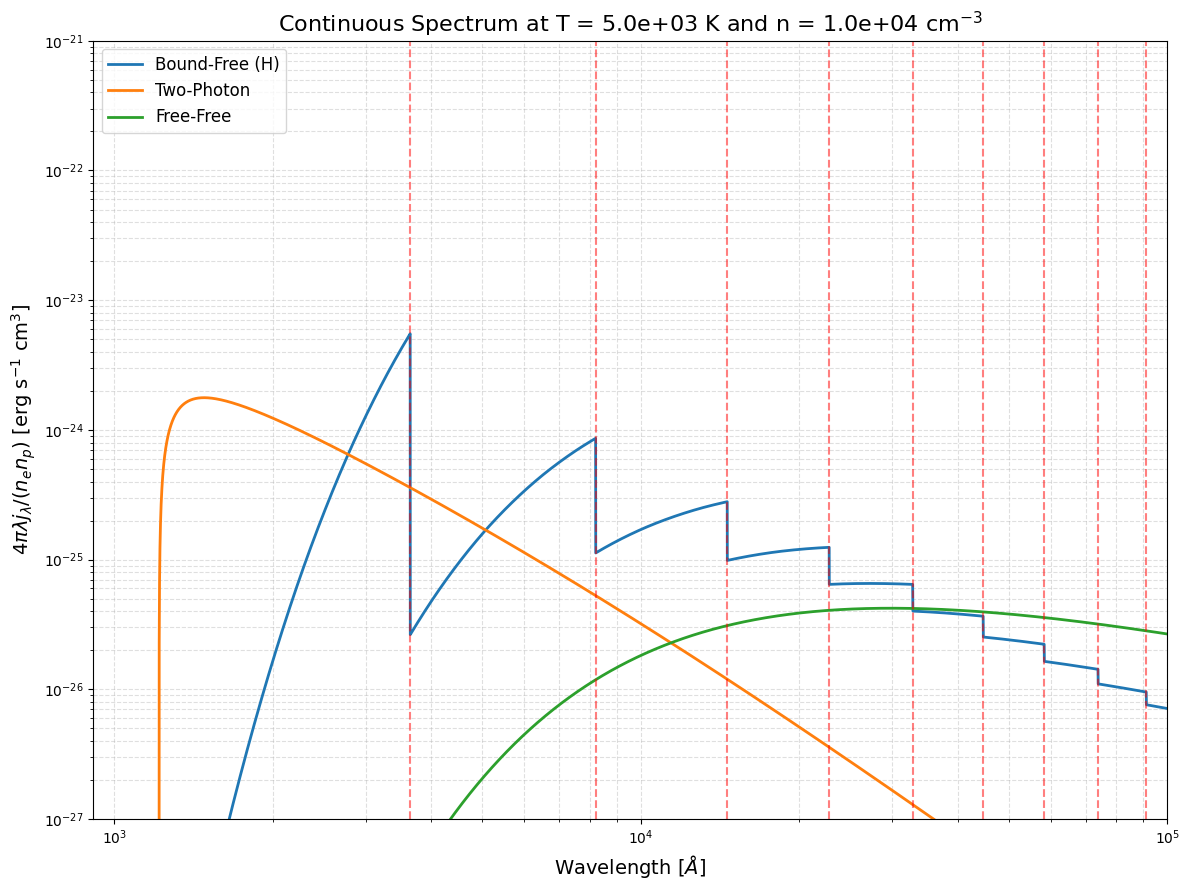

In [3]:
# example of how to plot the continuous spectrum at different temperature and density
C = pn.Continuum()
temp = 5e3 # in K
dense = 1e4 # in cm^-3

# created log-spaced wavelength array
rydberg_c = 10973731.568 # in m^-1
initial_wl_m = 1/rydberg_c # in m
initial_wl_A = initial_wl_m * 1e10 # in Angstrom
final_wl_A = 1e5 # in Angstrom
num_wl_grid = int(1e4)
wl_array_A = np.logspace(np.log10(initial_wl_A), np.log10(final_wl_A), num_wl_grid)
wl_array_A = wl_array_A[wl_array_A >= 912] # restrict to λ ≥ 912 Å (Lyman limit), as continuum is not defined below this in PyNeb

# compute emission components
cont_H = C.get_continuum(tem = temp, den = dense, wl = wl_array_A, HI_label = None, cont_HI = True, cont_HeI = False, cont_HeII = False, cont_2p = False, cont_ff = False) # bound-free emission
cont_2p = C.get_continuum(tem = temp, den = dense, wl = wl_array_A, HI_label = None, cont_HI = False, cont_HeI = False, cont_HeII = False, cont_2p = True, cont_ff = False) # two-photon emission
cont_ff = C.get_continuum(tem = temp, den = dense, wl = wl_array_A, HI_label = None, cont_HI = False, cont_HeI = False, cont_HeII = False, cont_2p = False, cont_ff = True) # free-free emission

# plot emission spectrum
plt.figure(figsize = (12, 9))
plt.plot(wl_array_A, cont_H * wl_array_A, label = "Bound-Free (H)", linewidth = 2)
plt.plot(wl_array_A, cont_2p * wl_array_A, label = "Two-Photon", linewidth = 2)
plt.plot(wl_array_A, cont_ff * wl_array_A, label = "Free-Free", linewidth = 2)
plt.xlim(np.min(wl_array_A), np.max(wl_array_A))
plt.ylim(1e-27, 1e-21)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Wavelength [$\AA$]", fontsize = 14)
plt.ylabel(r"$4\pi\lambda j_\lambda / (n_e n_p)$ [erg s$^{-1}$ cm$^3$]", fontsize = 14)
plt.title(f"Continuous Spectrum at T = {temp:.1e} K and n = {dense:.1e} cm$^{{-3}}$", fontsize = 16)
plt.legend(fontsize = 12)
plt.grid(True, which = "both", linestyle = "--", alpha = 0.4)

# draw the line to see jump in bound-free emission
final_wl_m = final_wl_A * 1e-10
maximum_level = np.sqrt(rydberg_c * final_wl_m)
maximum_level = int(np.floor(maximum_level))

for i in range(1, maximum_level + 1):
    wl_edge_A = (i**2 / rydberg_c) * 1e10
    if wl_edge_A >= 912:
        plt.axvline(x = wl_edge_A, linestyle = "--", color = 'red', alpha = 0.5)

plt.tight_layout()
plt.show()

The problem is that the **PyNeb** package can only be used to plot a continuous spectrum if you know the temperature and density of your object. However, in observations, what you typically have are the temperature and density for each pixel, so it becomes very difficult to use PyNeb directly to plot the continuum.

This repository is designed to help you plot the continuous spectrum of your dataset. The plot above is just an example of what we are aiming to obtain.

Another thing to consider is that the continuous spectrum alone cannot fully explain the behavior of your data. Therefore, we will use the **yt** package to generate slice, projection, and phase plots to show the relationships between different variables across pixels.

After this point, this repository provides the functions needed to plot both the projection plots and the continuous spectrum. However, if you do not need the full version of this repository and only want to use certain parts of it, this notebook is also a good option to explore.

### Loading Simulation Data (assume that you already downloaded the data from this repository)

In [4]:
# define cell fields
cell_fields = [
    "Density",                  # gas density
    "x-velocity",               # velocity in x direction
    "y-velocity",               # velocity in y direction
    "z-velocity",               # velocity in z direction
    "Pressure",                 # thermal pressure
    "Metallicity",              # metal mass fraction
    # "dark_matter_density",    # dark matter density
    "xHI",                      # neutral hydrogen fraction
    "xHII",                     # ionized hydrogen fraction
    "xHeII",                    # singly-ionized helium fraction
    "xHeIII"                    # doubly-ionized helium fraction      
]

# define extra particle fields
epf = [
    ("particle_family", "b"),       # particle type identifier
    ["particle_tag", "b"],          # particle id tag
    ["particle_birth_epoch", "d"],  # particle formation epoch
    ["particle_metallicity", "d"],  # particle metal mass fraction
]

# load dataset
f1 = "/Users/srnpt.p/Desktop/ASTR498/output_00273"     # where your dataset is
ds = yt.load(f1, fields = cell_fields, extra_particle_fields = epf, default_species_fields = "ionized")

# create a data container for analysis
ad = ds.all_data()  # contains all grid cells and particles

# extract star particle positions from the dataset
x_pos = np.array(ad["star", "particle_position_x"])
y_pos = np.array(ad["star", "particle_position_y"])
z_pos = np.array(ad["star", "particle_position_z"])

# calculate geometric center (mean of the position)
x_center = np.mean(x_pos)
y_center = np.mean(y_pos)
z_center = np.mean(z_pos)

# recenter positions relative to your center
x_pos = x_pos - x_center
y_pos = y_pos - y_center
z_pos = z_pos - z_center

# store the original center (before shifting)
ctr_at_code = np.array([x_center, y_center, z_center])  # in code units

# define spatial parameters for visualization (in parsec)
plt_wdth = 400      # total plot width: diameter = 400 pc
r_sf = 500          # radius for star formation region analysis
gas_res = 1000      # resolution for fixed-resolution buffer (pixels)

ds.fields

yt : [INFO     ] 2026-03-25 21:20:17,322 Parameters: current_time              = 4.311420483661945
yt : [INFO     ] 2026-03-25 21:20:17,322 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-03-25 21:20:17,323 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-25 21:20:17,323 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-03-25 21:20:17,323 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2026-03-25 21:20:17,323 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-03-25 21:20:17,324 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-03-25 21:20:17,324 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-03-25 21:20:17,324 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-03-25 21:20:17,324 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-03-25 21:20:20,813 This output has no 

### How to Visualize Slice and Projection Plots

yt : [INFO     ] 2026-03-25 21:20:25,442 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:25,442 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:25,443 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:25,443 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:25,445 Making a fixed resolution buffer of (('gas', 'number_density')) 800 by 800



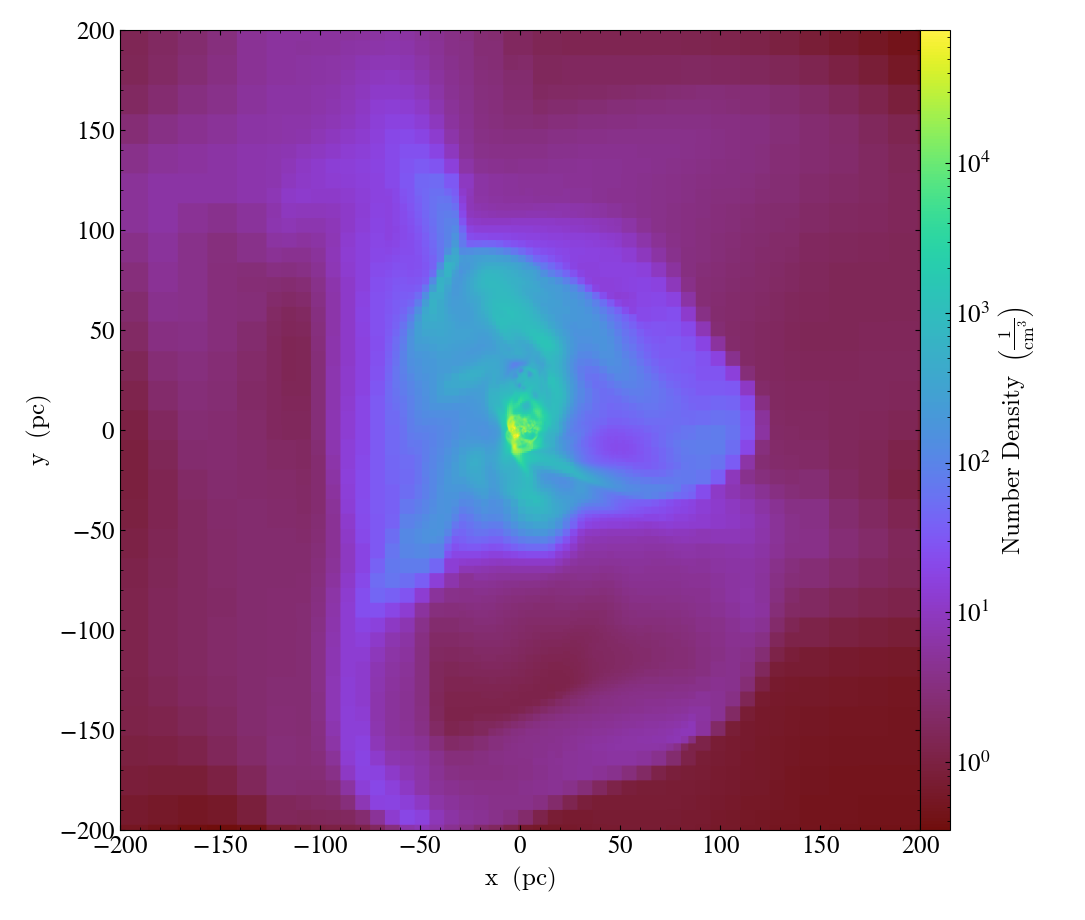

In [5]:
yt.SlicePlot(
    ds,                              # loaded dataset
    "z",                             # along z direction
    ("gas", "number_density"),       # field to visualize
    width = (plt_wdth, "pc"),        # plot width (in parsecs)
    center = ctr_at_code             # center position (in code units)
)

yt : [INFO     ] 2026-03-25 21:20:30,040 Projection completed
yt : [INFO     ] 2026-03-25 21:20:30,041 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:30,041 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:30,042 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:30,042 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:30,043 Making a fixed resolution buffer of (('gas', 'number_density')) 800 by 800



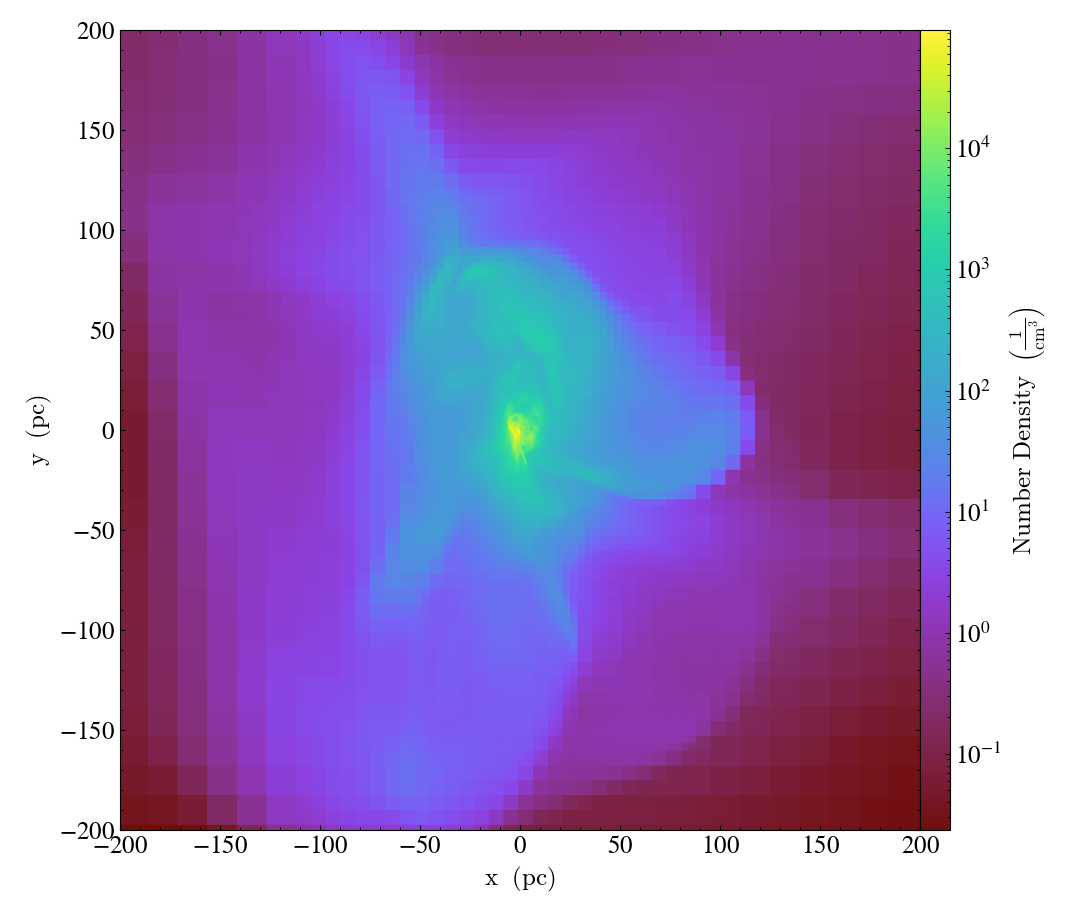

In [6]:
yt.ProjectionPlot(
    ds,                                         # loaded dataset
    "z",                                        # along z direction
    ("gas", "number_density"),                  # field to visualize
    width = (plt_wdth, "pc"),                   # plot width (in parsecs)
    weight_field = ("gas", "number_density"),   # weight field
    center = ctr_at_code                        # center position (in code units)
)

The problem with the **yt** package is that, if you want to plot the star distribution, you cannot overlay it directly on top of the projection plot. Even though this feature exists, it does not seem to work reliably in practice.

Additionally, the units shown in the plot are not correct, as we have not taken into account both the proton and electron number densities. Therefore, instead of using **yt** to display the result, we use **Matplotlib**.

<>:81: SyntaxWarning: invalid escape sequence '\o'
<>:81: SyntaxWarning: invalid escape sequence '\o'
/var/folders/kn/jn6lwb5n6tj0k4ss71gbbdhr0000gn/T/ipykernel_61289/619661559.py:81: SyntaxWarning: invalid escape sequence '\o'
  cbar2.set_label("Stellar Mass Density [M$_\odot$ pc$^{-2}$]")
yt : [INFO     ] 2026-03-25 21:20:32,972 Projection completed
yt : [INFO     ] 2026-03-25 21:20:32,972 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:32,973 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:32,974 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:20:32,974 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:20:32,974 Making a fixed resolution buffer of (('gas', 'number_density')) 800 by 800


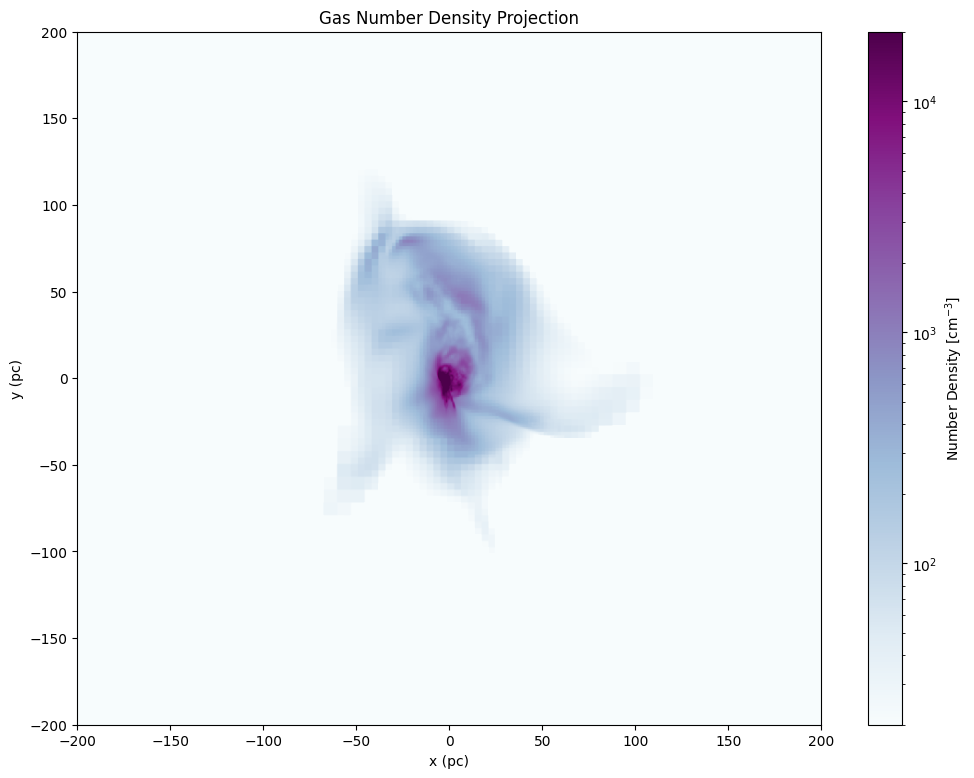

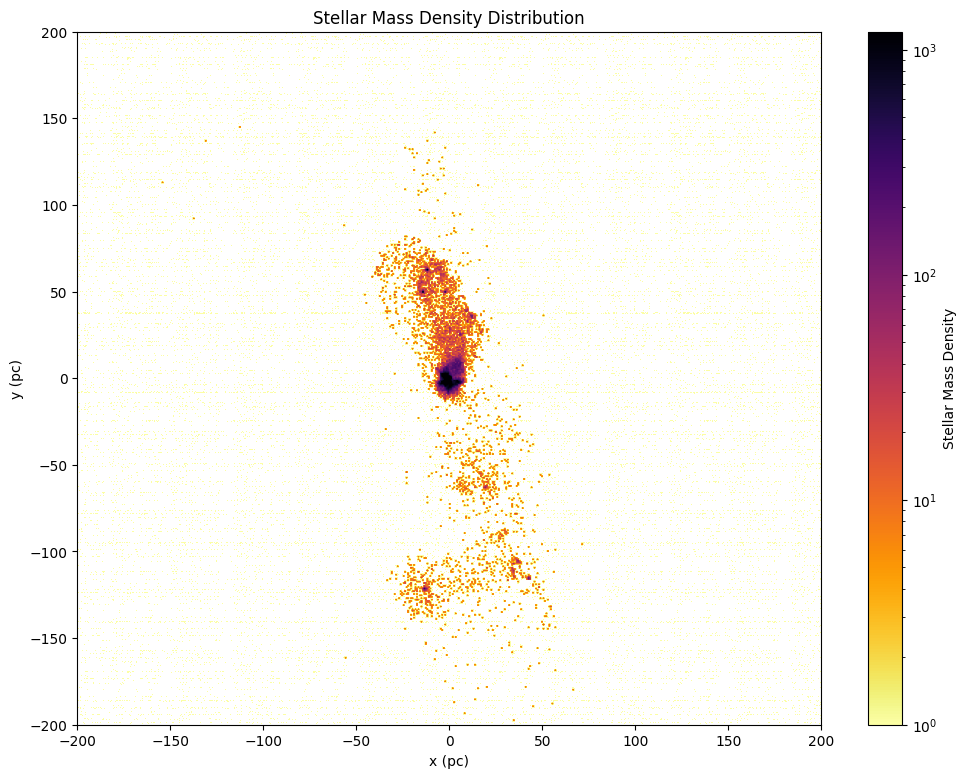

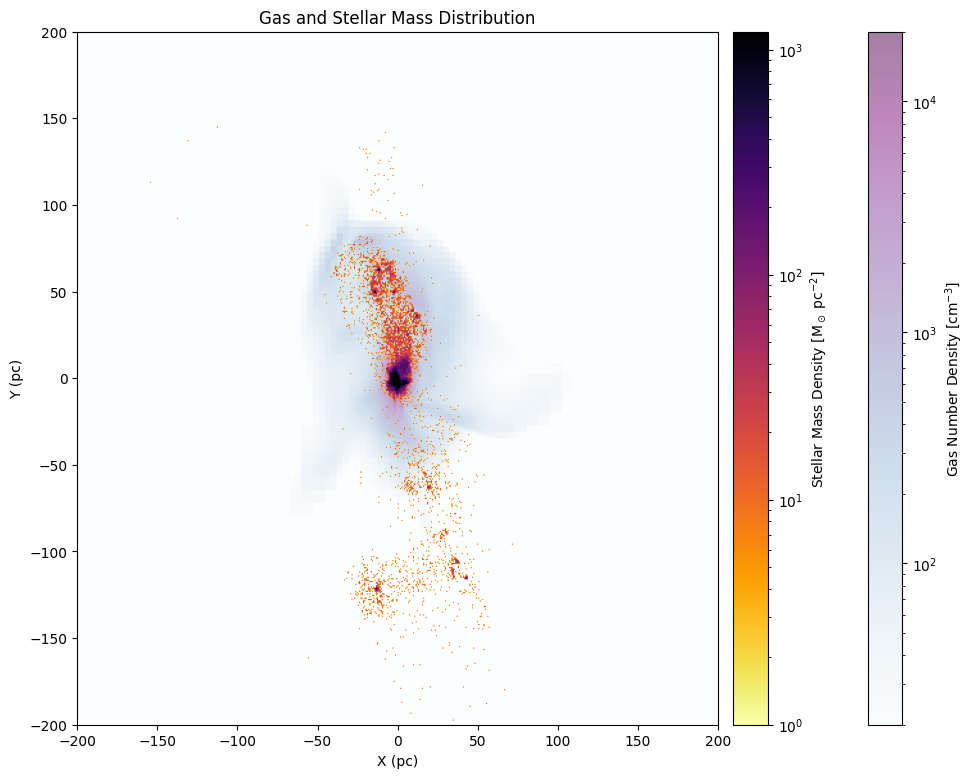

In [7]:
# generate projection plot using yt
p = yt.ProjectionPlot(
    ds,                                         # loaded dataset
    "z",                                        # along z direction
    ("gas", "number_density"),                  # field to visualize
    width = (plt_wdth, "pc"),                   # plot width (in parsecs)
    weight_field = ("gas", "number_density"),   # weight field
    center = ctr_at_code                        # center position (in code units)
)

# extract pixel data for plotting
p_frb = p.frb                                       # fixed-resolution buffer
p_img = np.array(p_frb["gas", "number_density"])    # convert field to numpy array

# prepare particle data (star)
star_bins = int(5e2)                                                                        # number of bins for particle distribution
star_mass = np.ones_like(x_pos) * 10                                                        # particle masses (10 units each)
pop2_xyz = np.array(ds.arr(np.vstack([x_pos, y_pos, z_pos]), "code_length").to("pc")).T     # particle positions (in parsecs)

# configure plot appearance
extent_dens = [-plt_wdth/2, plt_wdth/2, -plt_wdth/2, plt_wdth/2]    # plot boundaries [pc]
gas_range = (20, 2e4)                                               # density range for color mapping (in cm^-3)
norm_gas = LogNorm(vmin = gas_range[0], vmax = gas_range[1])        # logarithmic color scaling

# projection plot using matplotlib
plt.figure(figsize = (12, 9))
plt.imshow(p_img, norm = norm_gas, extent = extent_dens, origin = "lower", aspect = "auto", cmap = "BuPu")
plt.colorbar(label = r"Number Density [cm$^{-3}$]")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.title("Gas Number Density Projection")
plt.xlim(-plt_wdth/2, plt_wdth/2)
plt.ylim(-plt_wdth/2, plt_wdth/2)
plt.show()

# 2D histogram of stellar mass density
stellar_mass_dens, _, _ = np.histogram2d(
    pop2_xyz[:, 0],                 # x-positions (in pc)
    pop2_xyz[:, 1],                 # y-positions (in pc)
    bins = star_bins,               # number of bins (resolution)
    weights = star_mass,            # mass-weighted particles
    range = [                       # histogram range (match gas plot extent)
        [-plt_wdth/2, plt_wdth/2],
        [-plt_wdth/2, plt_wdth/2]
    ],
)
stellar_mass_dens = stellar_mass_dens.T  # transpose for correct imshow orientation

# remove noise
stellar_mass_dens = np.where(stellar_mass_dens <= 1, 0, stellar_mass_dens)

# configure plot appearance
stellar_range = (1, 1200)                                               
norm_star = LogNorm(vmin = stellar_range[0], vmax = stellar_range[1])

# scatter plot of stellar mass distribution
plt.figure(figsize = (12, 9))
plt.imshow(stellar_mass_dens, norm = norm_star, extent = extent_dens, origin = "lower", aspect = "auto", cmap = "inferno_r")
plt.colorbar(label = "Stellar Mass Density")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.title("Stellar Mass Density Distribution")
plt.xlim(-plt_wdth/2, plt_wdth/2)
plt.ylim(-plt_wdth/2, plt_wdth/2)
plt.show()

# combine plot
fig, ax = plt.subplots(figsize = (12, 9))

# plot gas number density
img1 = ax.imshow(p_img, norm = norm_gas, extent = extent_dens, origin = "lower", aspect = "auto", cmap = "BuPu", alpha = 0.5)
cbar1 = fig.colorbar(img1, ax = ax, orientation = "vertical", pad = 0.02)
cbar1.set_label(r"Gas Number Density [cm$^{-3}$]")

# create transparency mask: set alpha = 0 where stellar mass is low
alpha_star = np.where(stellar_mass_dens <= 1, 0.0, 1.0)

# overlay stellar mass density
img2 = ax.imshow(stellar_mass_dens, norm = norm_star, extent = extent_dens, origin = "lower", aspect = "auto", cmap = "inferno_r", alpha = alpha_star)
cbar2 = fig.colorbar(img2, ax = ax, orientation = "vertical", pad = 0.02)
cbar2.set_label("Stellar Mass Density [M$_\odot$ pc$^{-2}$]")
ax.set(
    xlabel = "X (pc)",
    ylabel = "Y (pc)",
    title = "Gas and Stellar Mass Distribution",
    xlim = (-plt_wdth/2, plt_wdth/2),
    ylim = (-plt_wdth/2, plt_wdth/2)
)
plt.show()

### Visualization of Dataset Results Using a Single Filter

The most recent instrument we use to study gas and stars is the James Webb Space Telescope (JWST). To study these components, we need filters to select specific ranges of wavelength. There are two instruments we can use to study this:

- NIRSpec: Near-Infrared Instrument. Range: 0.6 - 4.9 microns. It is used to study ionized gas, stellar populations, and emission lines.

- MIRI: Mid-Infrared Instrument. Range: 4.9 - 27.9 microns. It is used to study cooler components such as dust, molecular gas, and embedded star-forming regions. 

In this notebook example, we will use one of the filters from NIRSpec, which you can download from this repository. In reality, astronomical objects are moving, which causes their observed spectra to shift due to redshift. To make the analysis easier, we apply the concept of relative motion by treating the object as stationary and instead shifting the filter according to the redshift.

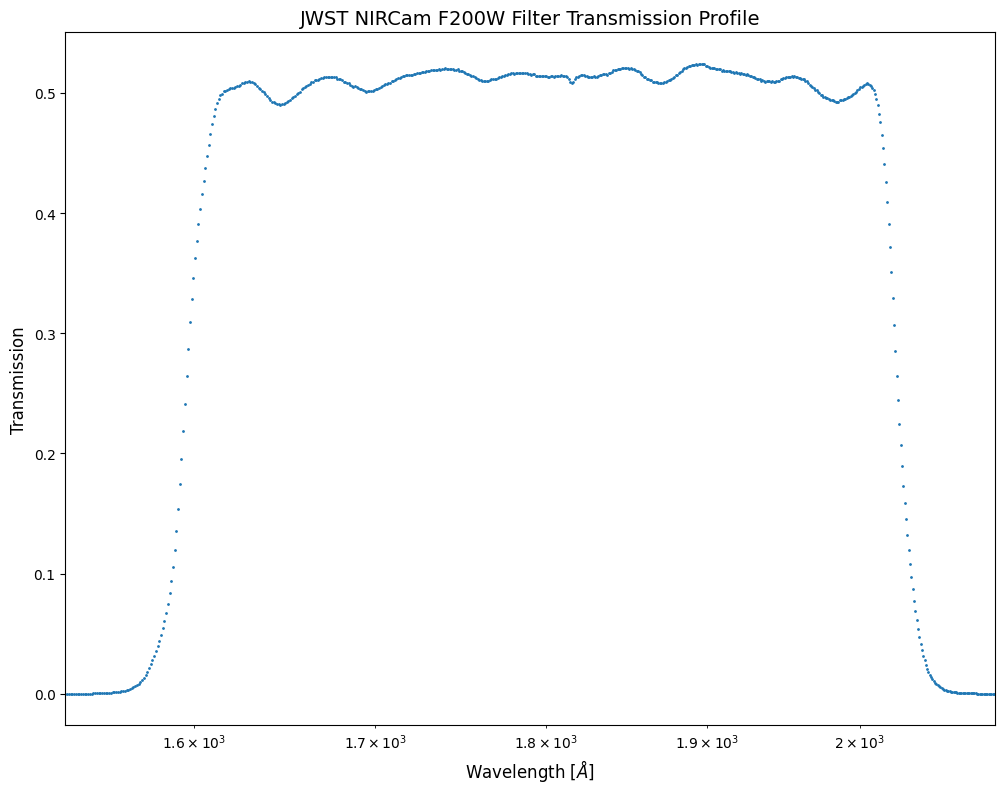

In [8]:
# define redshift
z = 10

# load F200W filter data
F200W = np.loadtxt("F200W_filter.txt", skiprows = 1)

# create dataframe
df_F200W = pd.DataFrame(F200W, columns = ["Wavelength [Microns]", "Output"])

# convert filter wavelengths from microns to Angstroms: accounting for redshift
wavelength_F200W = df_F200W["Wavelength [Microns]"] * 1e4 / (1 + z)

# extract transmission values
output_F200W = df_F200W["Output"]

# calculate integral of filter response
integral_filter_F200W = np.abs(np.trapz(output_F200W * wavelength_F200W, wavelength_F200W))

# plot the F200W filter transmission curve
plt.figure(figsize = (12, 9))
plt.scatter(wavelength_F200W, output_F200W, s = 1)
plt.xlim(np.min(wavelength_F200W), np.max(wavelength_F200W))
plt.xscale("log")
plt.xlabel(r"Wavelength [$\AA$]", fontsize = 12)
plt.ylabel("Transmission", fontsize = 12)
plt.title("JWST NIRCam F200W Filter Transmission Profile", fontsize = 14)
plt.show()

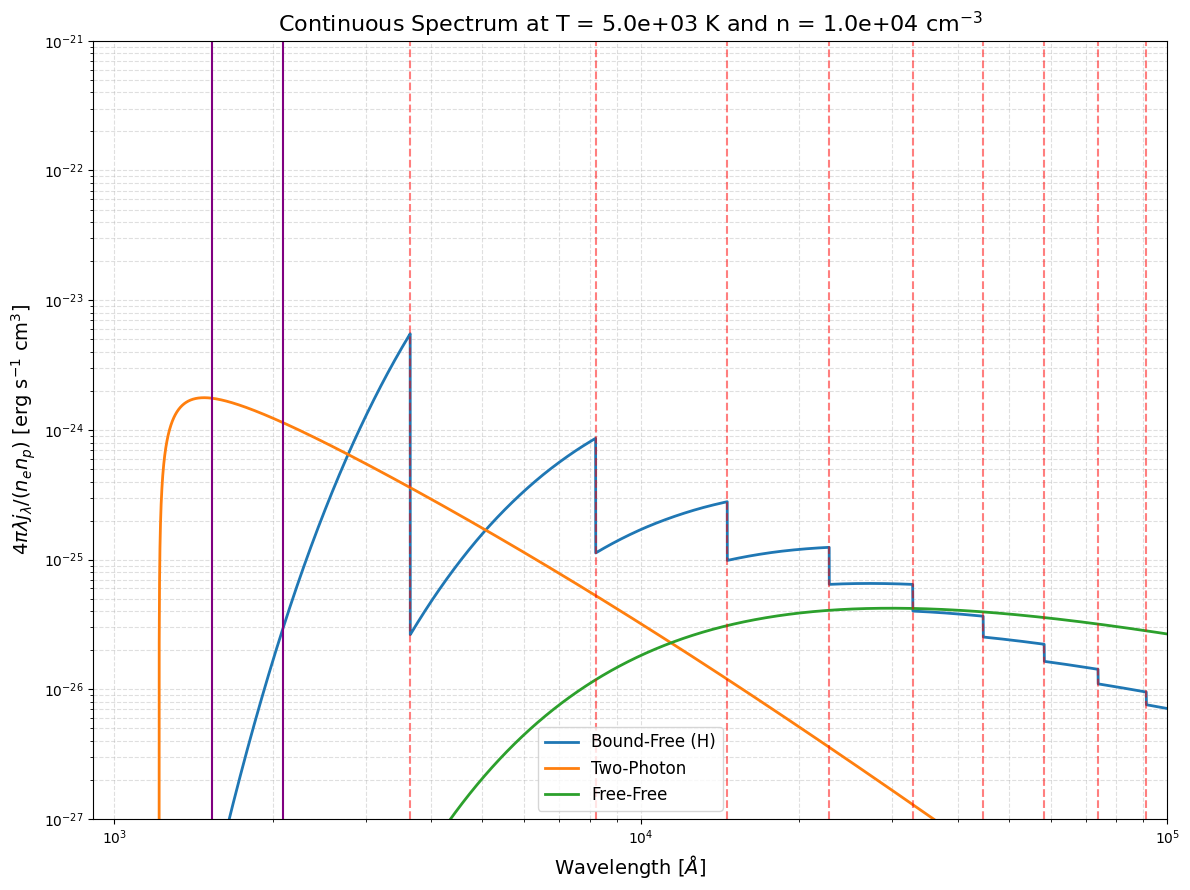

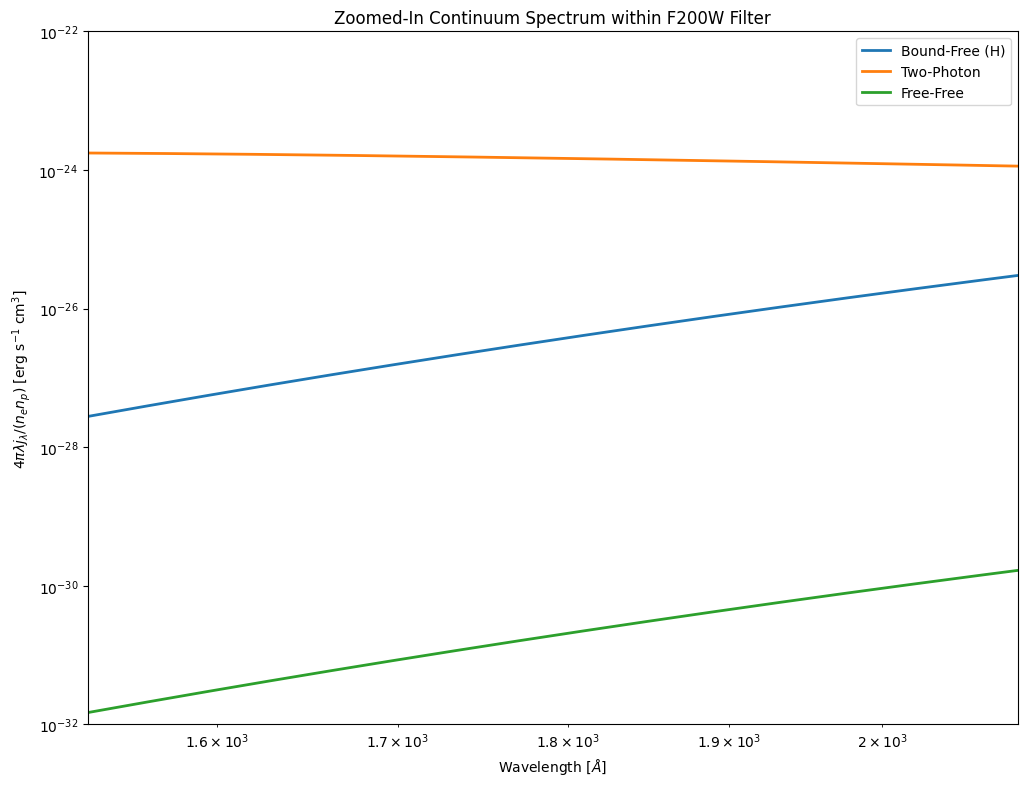

In [9]:
# apply the filter to the spectrum to see the wavelength range being observed
plt.figure(figsize = (12, 9))
plt.plot(wl_array_A, cont_H * wl_array_A, label = "Bound-Free (H)", linewidth = 2)
plt.plot(wl_array_A, cont_2p * wl_array_A, label = "Two-Photon", linewidth = 2)
plt.plot(wl_array_A, cont_ff * wl_array_A, label = "Free-Free", linewidth = 2)
plt.xlim(np.min(wl_array_A), np.max(wl_array_A))
plt.ylim(1e-27, 1e-21)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Wavelength [$\AA$]", fontsize = 14)
plt.ylabel(r"$4\pi\lambda j_\lambda / (n_e n_p)$ [erg s$^{-1}$ cm$^3$]", fontsize = 14)
plt.title(f"Continuous Spectrum at T = {temp:.1e} K and n = {dense:.1e} cm$^{{-3}}$", fontsize = 16)
plt.legend(fontsize = 12)
plt.grid(True, which = "both", linestyle = "--", alpha = 0.4)

# draw the line to see jump in bound-free emission
final_wl_m = final_wl_A * 1e-10
maximum_level = np.sqrt(rydberg_c * final_wl_m)
maximum_level = int(np.floor(maximum_level))

for i in range(1, maximum_level + 1):
    wl_edge_A = (i**2 / rydberg_c) * 1e10
    if wl_edge_A >= 912:
        plt.axvline(x = wl_edge_A, linestyle = "--", color = 'red', alpha = 0.5)

# draw the line to see range of the filter
plt.axvline(x = np.min(wavelength_F200W), color = 'purple')
plt.axvline(x = np.max(wavelength_F200W), color = 'purple')
plt.tight_layout()
plt.show()

# zoom into the F200W filter range
tolerance = 1e-10  # small buffer to ensure complete wavelength coverage
mask = (wl_array_A >= np.min(wavelength_F200W) - tolerance) & (wl_array_A <= np.max(wavelength_F200W) + tolerance)

# plot continuum components within the F200W filter range
plt.figure(figsize = (12, 9))
plt.plot(wl_array_A[mask], cont_H[mask] * wl_array_A[mask], label = "Bound-Free (H)", linewidth = 2)
plt.plot(wl_array_A[mask], cont_2p[mask] * wl_array_A[mask], label = "Two-Photon", linewidth = 2)
plt.plot(wl_array_A[mask], cont_ff[mask] * wl_array_A[mask], label = "Free-Free", linewidth = 2)
plt.legend()
plt.xlim(np.min(wavelength_F200W), np.max(wavelength_F200W))
plt.ylim(1e-32, 1e-22)                
plt.xscale("log")                     
plt.yscale("log")                     
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"$4\pi\lambda j_\lambda / (n_e n_p)$ [erg s$^{-1}$ cm$^3$]")
plt.title("Zoomed-In Continuum Spectrum within F200W Filter")
plt.show()

In [10]:
# interpolate continuum components onto the filter grid
cont_H_interp = interp1d(wl_array_A[mask], cont_H[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")
cont_2p_interp = interp1d(wl_array_A[mask], cont_2p[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")
cont_ff_interp = interp1d(wl_array_A[mask], cont_ff[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")

# apply filter transmission and calculate weighted fluxes
weighted_cont_H_interp = cont_H_interp(wavelength_F200W) * output_F200W
weighted_cont_2p_interp = cont_2p_interp(wavelength_F200W) * output_F200W
weighted_cont_ff_interp = cont_ff_interp(wavelength_F200W) * output_F200W

# integrate over the filter wavelength range
integral_cont_H = np.abs(np.trapz(weighted_cont_H_interp, wavelength_F200W))
integral_cont_2p = np.abs(np.trapz(weighted_cont_2p_interp, wavelength_F200W))
integral_cont_ff = np.abs(np.trapz(weighted_cont_ff_interp, wavelength_F200W))

# compute relative average fluxes: normalized by total filter integral
flux_avg_cont_H = integral_cont_H / integral_filter_F200W
flux_avg_cont_2p = integral_cont_2p / integral_filter_F200W
flux_avg_cont_ff = integral_cont_ff / integral_filter_F200W
print(f"The flux average of Bound-Free (H) is {flux_avg_cont_H:.3e}")
print(f"The flux average of Two-Photon is {flux_avg_cont_2p:.3e}")
print(f"The flux average of Free-Free (ff) is {flux_avg_cont_ff:.3e}")

The flux average of Bound-Free (H) is 3.369e-30
The flux average of Two-Photon is 8.025e-28
The flux average of Free-Free (ff) is 1.847e-34


Because the dataset contains so many pixels, calculating the flux for each pixel directly would take too much time.

To make this easier, we first create a DataFrame over a grid of temperature and density values with the filter already applied. Then, for each pixel, we simply interpolate from this table instead of recalculating the continuum every time.

The code cell below combines everything you need to create interpolate table.

In [11]:
# setup parameter space for temperature grid
temp_min = 1e3
temp_max = 1e5
num_temp_grid = 50
temp_array = np.logspace(np.log10(temp_min), np.log10(temp_max), num_temp_grid)

# setup parameter space for density grid
dense_min = 1e-28
dense_max = 1e5
num_dense_grid = 50
dense_array = np.logspace(np.log10(dense_min), np.log10(dense_max), num_dense_grid)

# setup parameter space for wavelength grid (we already defined this earlier, but I include it here to summarize what you really need to create the table)
rydberg_c = 10973731.568 # in m^-1
initial_wl_m = 1/rydberg_c # in m
initial_wl_A = initial_wl_m * 1e10 # in Angstrom
final_wl_A = 1e5 # in Angstrom
num_wl_grid = int(1e4)
wl_array_A = np.logspace(np.log10(initial_wl_A), np.log10(final_wl_A), num_wl_grid)
wl_array_A = wl_array_A[wl_array_A >= 912] # restrict to λ ≥ 912 Å (Lyman limit), as continuum is not defined below this in PyNeb

# initialize result
result = []

# iterate over temperature and density grid
for tem in temp_array:
    for den in dense_array:

        # calculate continuum emission components
        cont_H = C.get_continuum(tem = tem, den = den, wl = wl_array_A, HI_label = None, cont_HI = True, cont_HeI = False, cont_HeII = False, cont_2p = False, cont_ff = False) # bound-free emission
        cont_2p = C.get_continuum(tem = tem, den = den, wl = wl_array_A, HI_label = None, cont_HI = False, cont_HeI = False, cont_HeII = False, cont_2p = True, cont_ff = False) # two-photon emission
        cont_ff = C.get_continuum(tem = tem, den = den, wl = wl_array_A, HI_label = None, cont_HI = False, cont_HeI = False, cont_HeII = False, cont_2p = False, cont_ff = True) # free-free emission

        # interpolate continuum components onto filter wavelength grid
        tolerance = 1e-10
        mask = (wl_array_A >= np.min(wavelength_F200W) - tolerance) & (wl_array_A <= np.max(wavelength_F200W) + tolerance)
        cont_H_interp = interp1d(wl_array_A[mask], cont_H[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")
        cont_2p_interp = interp1d(wl_array_A[mask], cont_2p[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")
        cont_ff_interp = interp1d(wl_array_A[mask], cont_ff[mask] * wl_array_A[mask], kind = "linear", fill_value = "extrapolate")

        # apply filter transmission and calculate weighted fluxes
        weighted_cont_H_interp = cont_H_interp(wavelength_F200W)
        weighted_cont_2p_interp = cont_2p_interp(wavelength_F200W)
        weighted_cont_ff_interp = cont_ff_interp(wavelength_F200W)

        # integrate over the filter wavelength range
        integral_cont_H = np.abs(np.trapz(weighted_cont_H_interp, wavelength_F200W))
        integral_cont_2p = np.abs(np.trapz(weighted_cont_2p_interp, wavelength_F200W))
        integral_cont_ff = np.abs(np.trapz(weighted_cont_ff_interp, wavelength_F200W))

        # compute relative average fluxes: normalized by total filter integral
        flux_avg_cont_H = integral_cont_H / integral_filter_F200W
        flux_avg_cont_2p = integral_cont_2p / integral_filter_F200W
        flux_avg_cont_ff = integral_cont_ff / integral_filter_F200W

        # store computed results
        result.append({
            "Temperature": tem,
            "Density": den,
            "Flux_avg_cont_H": flux_avg_cont_H,
            "Flux_avg_cont_2p": flux_avg_cont_2p,
            "Flux_avg_cont_ff": flux_avg_cont_ff
        })

# final results dataframe
df_results = pd.DataFrame(result)
df_results

/opt/anaconda3/lib/python3.12/site-packages/pyneb/core/continuum.py:135: RuntimeWarning: invalid value encountered in power
  A = 202.0 * (y * (1. - y) * (1. -(4. * y * (1 - y))**0.8) + 0.88 * ( y * (1 - y))**1.53 * (4. * y * (1 - y))**0.8)


,Temperature,Density,Flux_avg_cont_H,Flux_avg_cont_2p,Flux_avg_cont_ff
0,1000.0,1.000000e-28,1.679472e-39,1.135837e-26,3.326703e-58
1,1000.0,4.714866e-28,1.679472e-39,1.135837e-26,3.326703e-58
2,1000.0,2.222996e-27,1.679472e-39,1.135837e-26,3.326703e-58
3,1000.0,1.048113e-26,1.679472e-39,1.135837e-26,3.326703e-58
4,1000.0,4.941713e-26,1.679472e-39,1.135837e-26,3.326703e-58
...,...,...,...,...,...
2495,100000.0,2.023590e+02,1.949199e-28,3.940012e-28,2.972583e-28
2496,100000.0,9.540955e+02,1.949199e-28,3.815918e-28,2.972583e-28
2497,100000.0,4.498433e+03,1.949199e-28,3.322526e-28,2.972583e-28
2498,100000.0,2.120951e+04,1.949199e-28,2.064162e-28,2.972583e-28


Next step is to use this table with **yt**.

We build an interpolation function over temperature and density, then add it as a custom field in **yt** so the flux of each cell can be computed directly without recalculating the continuum emission.

However, the interpolated table only stores the temperature and density dependent part of the continuum emission. The physical continuum flux is proportional to the product of the proton and electron number densities, which is not included in the table.

The cell below shows how to multiply this density factor back in, so we can obtain the real physical flux of the dataset and display it in a projection plot.

In [12]:
# extract data from DataFrame
temp_df = df_results['Temperature'].values
dense_df = df_results['Density'].values
flux_avg_cont_H_df = df_results['Flux_avg_cont_H'].values
flux_avg_cont_2p_df = df_results['Flux_avg_cont_2p'].values
flux_avg_cont_ff_df = df_results['Flux_avg_cont_ff'].values

# combine temperature and density into (x, y) points
points = np.column_stack((temp_df, dense_df))

# set up interpolators for each continuum component
interp_func_cont_H  = LinearNDInterpolator(points, flux_avg_cont_H_df)
interp_func_cont_2p = LinearNDInterpolator(points, flux_avg_cont_2p_df)
interp_func_cont_ff = LinearNDInterpolator(points, flux_avg_cont_ff_df)


# helper interpolation + physical scaling function
def _interp_flux_scaled(data, interp_func):
    temperature     = data['gas', 'temperature'].value
    number_density  = data['gas', 'number_density'].value
    xHII            = data['ramses', 'xHII'].value
    nH_tot          = data['gas', 'H_nuclei_density'].value
    xHeII           = data['ramses', 'xHeII'].value
    xHeIII          = data['ramses', 'xHeIII'].value

    # proton and electron densities
    n_p = xHII * nH_tot
    n_e = nH_tot * (xHII + 0.08 * (xHeII + 2 * xHeIII))

    # clip extreme temperatures
    temperature = np.clip(temperature, temp_min, temp_max)

    # interpolation
    pts  = np.column_stack((temperature.flatten(), number_density.flatten()))
    flux = interp_func(pts)

    # apply physical scaling
    flux = (flux * n_p.flatten() * n_e.flatten()) / (4 * np.pi)

    # fill NaNs
    flux[np.isnan(flux)] = 1e-50

    return flux.reshape(temperature.shape)

# cont_H field function
def _flux_cont_H_field(field, data):
    return _interp_flux_scaled(data, interp_func_cont_H)

# cont_2p field function
def _flux_cont_2p_field(field, data):
    return _interp_flux_scaled(data, interp_func_cont_2p)

# cont_ff field function
def _flux_cont_ff_field(field, data):
    return _interp_flux_scaled(data, interp_func_cont_ff)

# total continuum: cont_H + cont_2p + cont_ff
def _flux_total_field(field, data):
    flux_cont_H  = _interp_flux_scaled(data, interp_func_cont_H)
    flux_cont_2p = _interp_flux_scaled(data, interp_func_cont_2p)
    flux_cont_ff = _interp_flux_scaled(data, interp_func_cont_ff)

    flux_total = flux_cont_H + flux_cont_2p + flux_cont_ff
    flux_total[np.isnan(flux_total)] = 1e-50

    return flux_total

In [13]:
# register continuum flux fields to the dataset
ds.add_field(
    ("gas", "flux_cont_H"),
    function = _flux_cont_H_field,
    sampling_type = "cell",
    units = "",
    force_override = True
)

ds.add_field(
    ("gas", "flux_cont_2p"),
    function = _flux_cont_2p_field,
    sampling_type = "cell",
    units = "",
    force_override = True
)

ds.add_field(
    ("gas", "flux_cont_ff"),
    function = _flux_cont_ff_field,
    sampling_type = "cell",
    units = "",
    force_override = True
)

ds.add_field(
    ("gas", "flux_total"),
    function = _flux_total_field,
    sampling_type = "cell",
    units = "",
    force_override = True
)

yt : [INFO     ] 2026-03-25 21:24:37,155 Projection completed
yt : [INFO     ] 2026-03-25 21:24:37,155 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:24:37,156 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:24:37,157 xlim = 0.491120 0.491223
yt : [INFO     ] 2026-03-25 21:24:37,157 ylim = 0.492725 0.492828
yt : [INFO     ] 2026-03-25 21:24:37,157 Making a fixed resolution buffer of (('gas', 'flux_cont_H')) 800 by 800



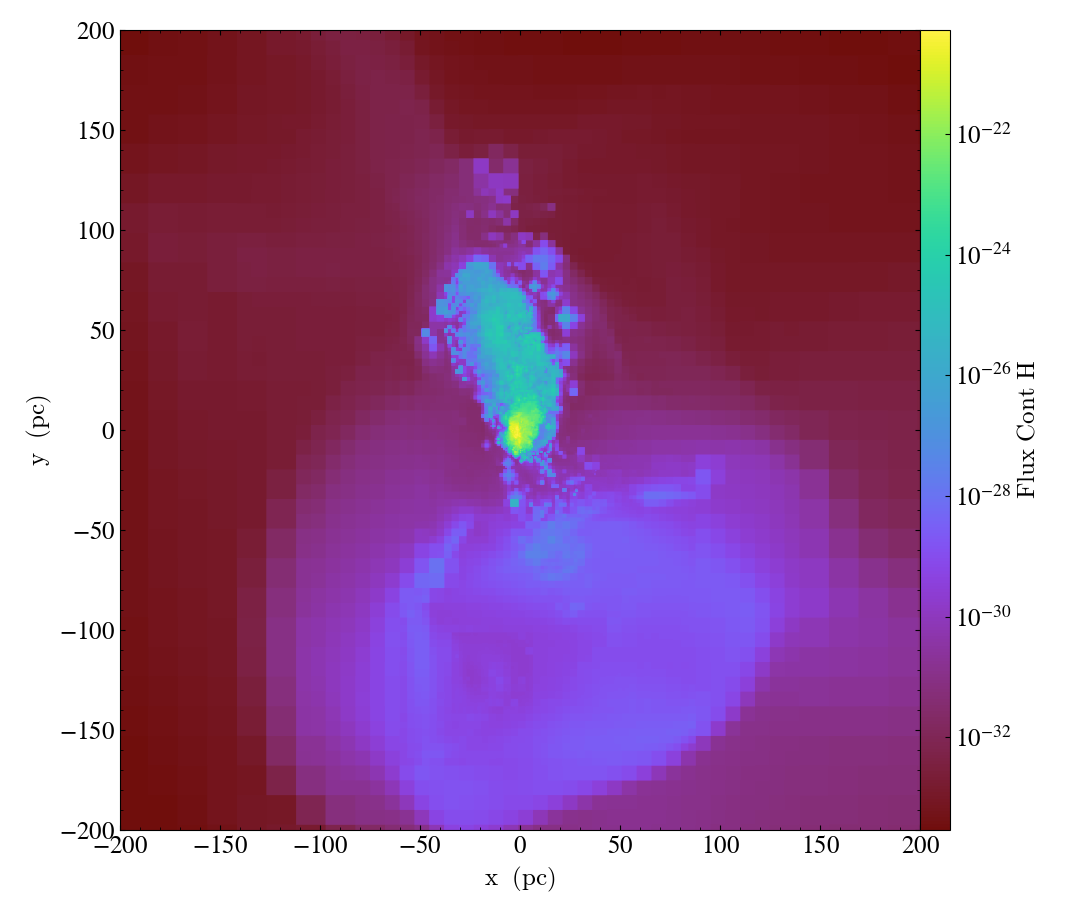

In [14]:
# plot projection for flux_cont_H
yt.ProjectionPlot(
    ds,
    "z",                             
    ("gas", "flux_cont_H"),           
    width = (plt_wdth, "pc"),         
    weight_field = ("gas", "density"),
    center = ctr_at_code              
)

### How to Visualize Phase Plot Using both Matplotlib and yt

/var/folders/kn/jn6lwb5n6tj0k4ss71gbbdhr0000gn/T/ipykernel_61289/1088072803.py:44: RuntimeWarning: invalid value encountered in divide
  hist_norm = np.where(hist_weight > 0, hist_flux / hist_weight, 0)


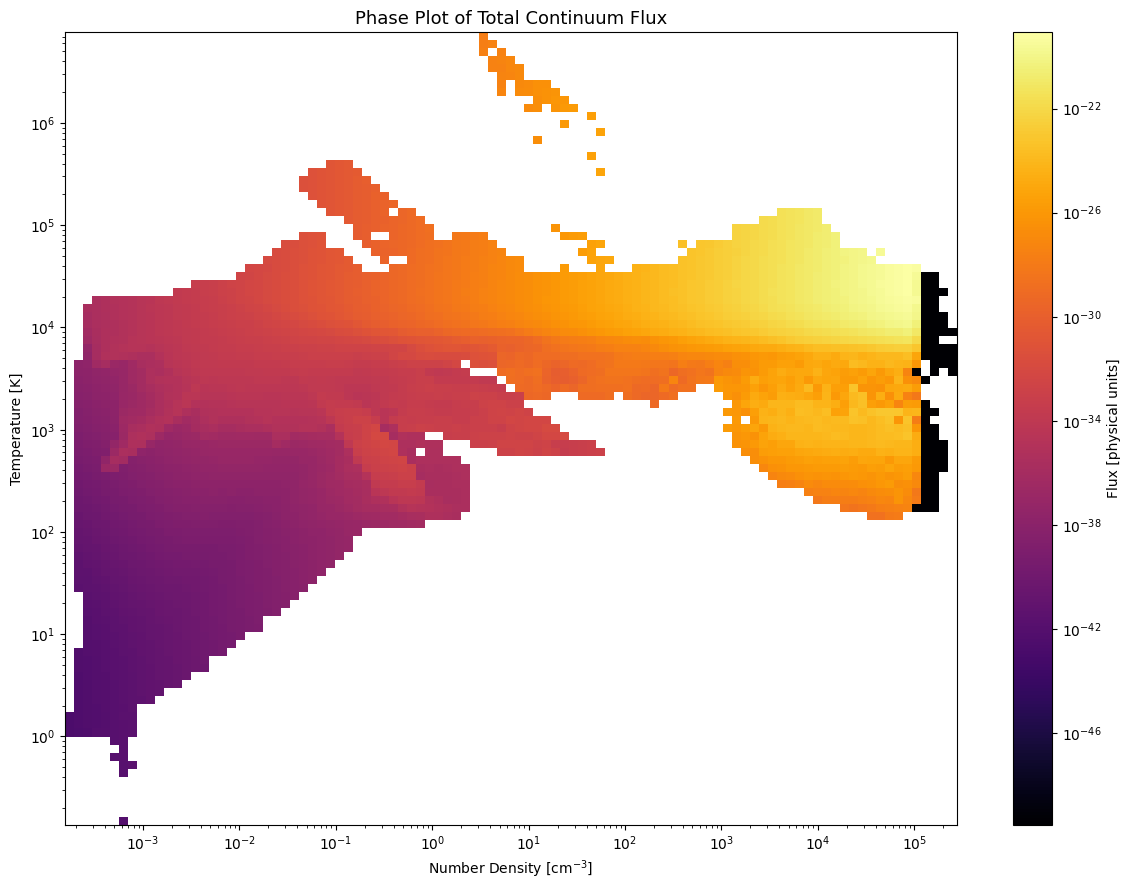

In [15]:
# access full gas dataset
ad = ds.all_data()

# extract fields
number_density = ad["gas", "number_density"].v
temperature    = ad["gas", "temperature"].to("K").v
flux_cont_H    = ad["gas", "flux_cont_H"].v
flux_cont_2p   = ad["gas", "flux_cont_2p"].v
flux_cont_ff   = ad["gas", "flux_cont_ff"].v
flux_total     = ad["gas", "flux_total"].v
density        = ad["gas", "density"].v

# replace non-finite values once
def clean(arr):
    return np.where(np.isfinite(arr), arr, 1e-50)

number_density = clean(number_density)
temperature    = clean(temperature)
flux_cont_H    = clean(flux_cont_H)
flux_cont_2p   = clean(flux_cont_2p)
flux_cont_ff   = clean(flux_cont_ff)
flux_total     = clean(flux_total)
density        = clean(density)

# bins FROM DATA (like yt)
density_bins     = np.logspace(np.log10(np.min(number_density)), np.log10(np.max(number_density)), 100)
temperature_bins = np.logspace(np.log10(np.min(temperature)), np.log10(np.max(temperature)), 100)

# yt-equivalent histograms
hist_flux, xedges, yedges = np.histogram2d(
    number_density,
    temperature,
    bins = [density_bins, temperature_bins],
    weights = flux_total * density
)

hist_weight, _, _ = np.histogram2d(
    number_density,
    temperature,
    bins = [density_bins, temperature_bins],
    weights = density
)

hist_norm = np.where(hist_weight > 0, hist_flux / hist_weight, 0)
masked = np.ma.masked_less_equal(hist_norm.T, 1e-50)

# plot
fig, ax = plt.subplots(figsize = (12, 9))
pcm = ax.pcolormesh(
    xedges,
    yedges,
    masked,
    norm = LogNorm(),
    cmap = "inferno",
    shading = "auto"
)
fig.colorbar(pcm, ax = ax, label = "Flux [physical units]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number Density [cm$^{-3}$]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Phase Plot of Total Continuum Flux", fontsize = 13)
plt.tight_layout()
plt.show()


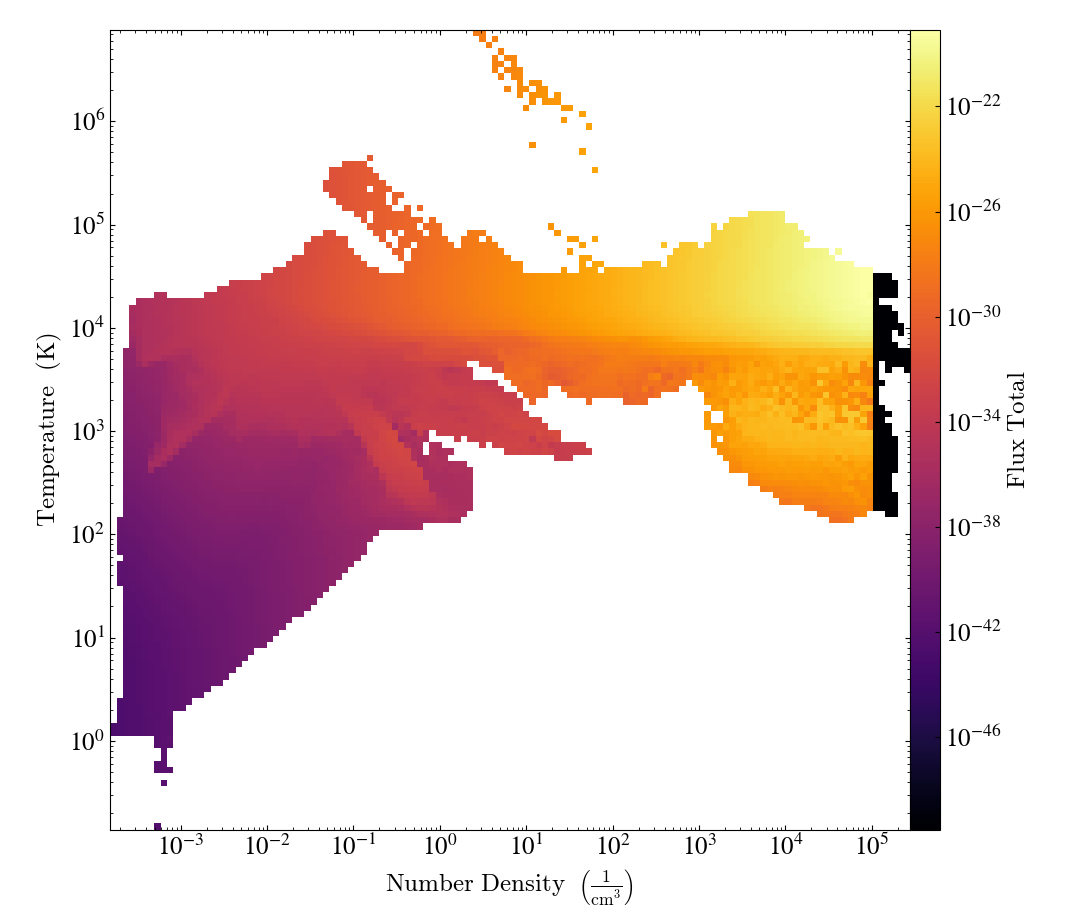

In [16]:
# phase plot from yt
yt.PhasePlot(
    ad,                   
    ("gas", "number_density"),       
    ("gas", "temperature"),         
    ("gas", "flux_total"),          
    weight_field = ("gas", "density")
).set_cmap(
    ("gas", "flux_total"), "inferno"
).show()